## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

In [3]:
plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [6]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Import dataset

In [7]:
car = pd.read_csv("data/car data.csv")
car.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Inspect the Dataset

### Shape

In [8]:
car.shape

(301, 9)

### Info and describe

In [9]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [10]:
car.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Checking null values¶

In [11]:
car.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [12]:
car.columns = car.columns.str.lower()
car.columns

Index(['car_name', 'year', 'selling_price', 'present_price', 'kms_driven',
       'fuel_type', 'seller_type', 'transmission', 'owner'],
      dtype='object')

## Cleaning the Dataset

### Handling duplicates and inconsistency

In [13]:
car = car.drop_duplicates().reset_index(drop=True)
car.shape

(299, 9)

In [14]:
for col in ['car_name','fuel_type', 'seller_type', 'transmission']:
    car[col] = car[col].str.capitalize()

### Feature engineering

In [15]:
car["brand"] = car["car_name"].str.split().str[0]
car["brand"].unique()

array(['Ritz', 'Sx4', 'Ciaz', 'Wagon', 'Swift', 'Vitara', 'S', 'Alto',
       'Ertiga', 'Dzire', 'Ignis', '800', 'Baleno', 'Omni', 'Fortuner',
       'Innova', 'Corolla', 'Etios', 'Camry', 'Land', 'Royal', 'Um',
       'Ktm', 'Bajaj', 'Hyosung', 'Mahindra', 'Honda', 'Yamaha', 'Tvs',
       'Hero', 'Activa', 'Suzuki', 'I20', 'Grand', 'I10', 'Eon', 'Xcent',
       'Elantra', 'Creta', 'Verna', 'City', 'Brio', 'Amaze', 'Jazz'],
      dtype=object)

In [16]:
current_year = 2026
car["car_age"] = current_year - car["year"]

## Explanatory Data Analysis (EDA)

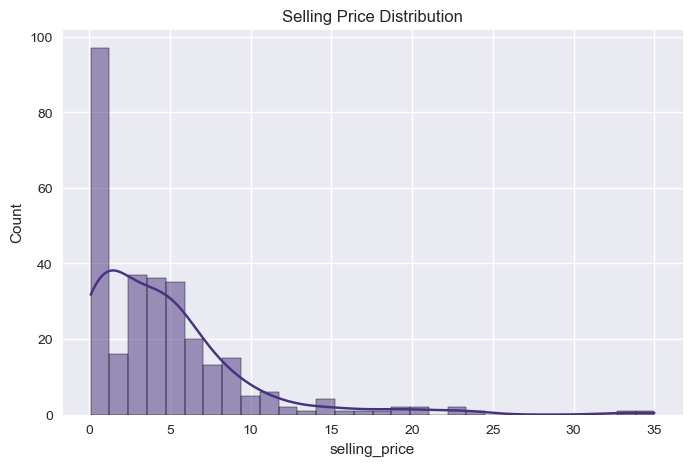

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(car["selling_price"], bins=30, kde=True)
plt.title("Selling Price Distribution")
plt.show()

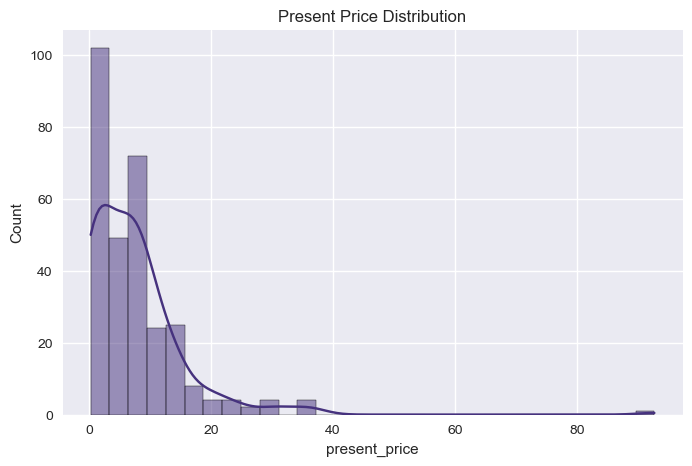

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(car["present_price"], bins=30, kde=True)
plt.title("Present Price Distribution")
plt.show()

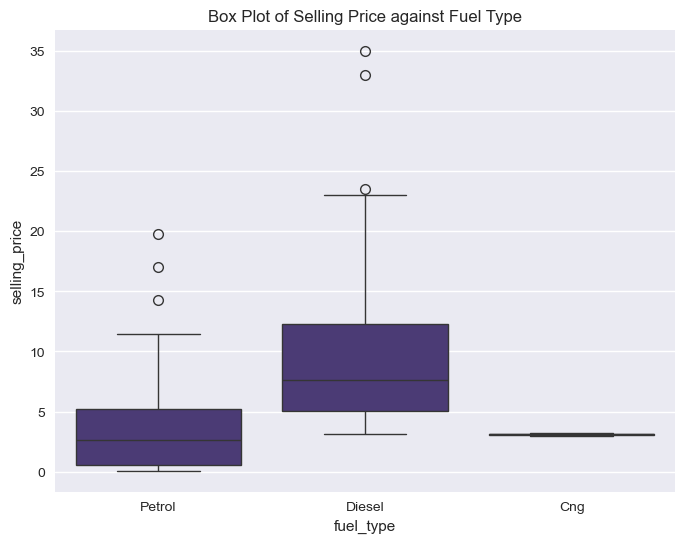

In [19]:
plt.figure(figsize=(8,6))
sns.boxplot(x="fuel_type",y="selling_price",data=car)
plt.title("Box Plot of Selling Price against Fuel Type")
#plt.yticks(np.arange(0, 36, step=1))
plt.show()

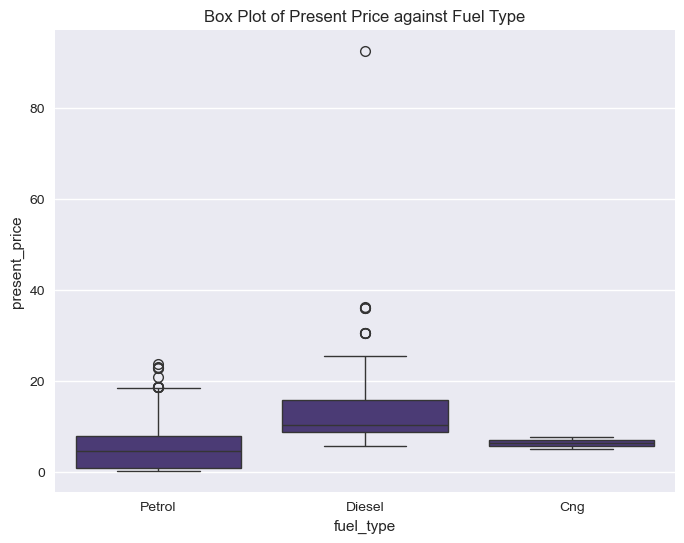

In [20]:
plt.figure(figsize=(8,6))
sns.boxplot(x="fuel_type",y="present_price",data=car)
plt.title("Box Plot of Present Price against Fuel Type")
plt.show()

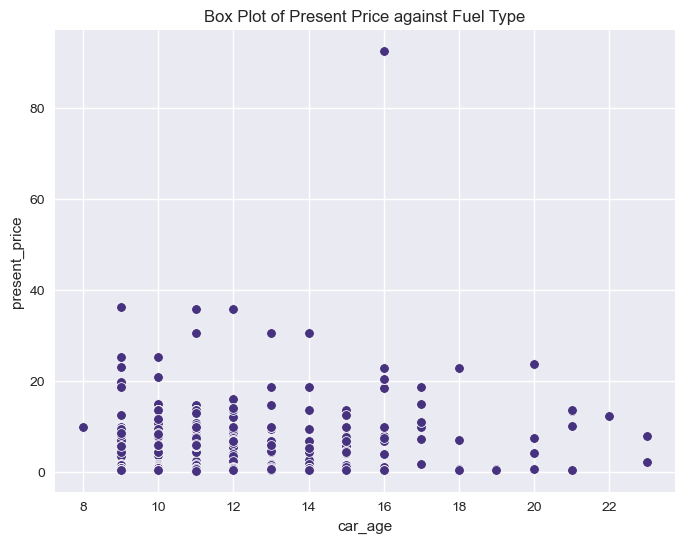

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(y="present_price",x="car_age",data=car)
plt.title("Box Plot of Present Price against Fuel Type")
plt.show()

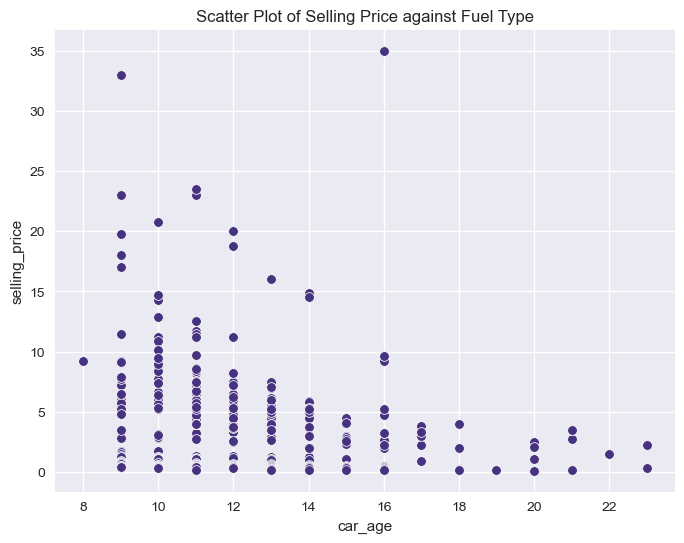

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(y="selling_price",x="car_age",data=car)
plt.title("Scatter Plot of Selling Price against Fuel Type")
plt.show()

## Correlation Heatmap

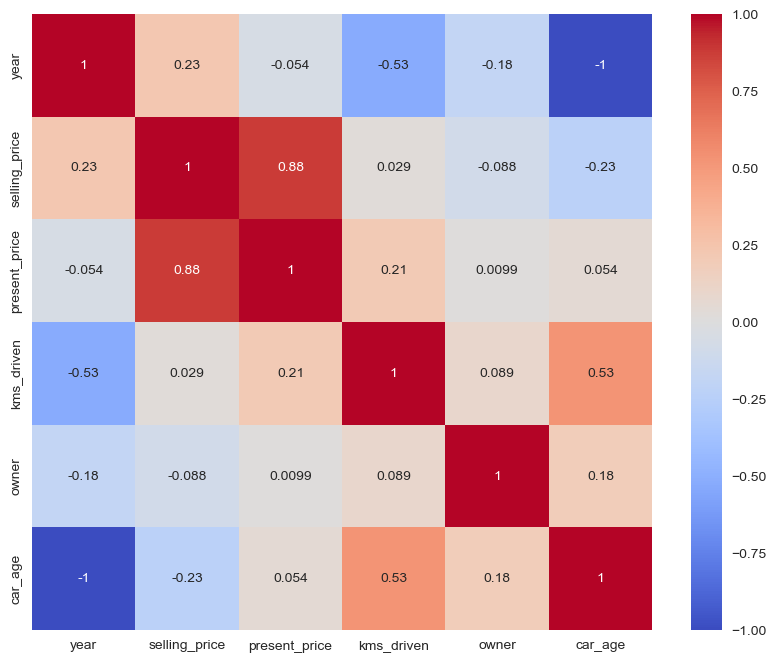

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(car.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.show()

## Encode Categorical Variables

In [24]:
X = car.drop("selling_price", axis=1)
y = car["selling_price"]

In [25]:
# Identify categorical columns
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

In [26]:
# Create preprocessing pipeline.
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))])
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

preprocessor = ColumnTransformer(transformers=[("cat", categorical_transformer, cat_cols), ("num", numeric_transformer, num_cols)])

## Train/Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Train Regression Models

### Linear Regression

In [28]:
lr_model = Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])
lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['car_name', 'fuel_type', 'seller_type', 'transmission', 'brand'], dtype='object')),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['year', 'present_price', 'kms_driven', 'owner', 'car_age'], dtype='object'))])),
                ('model', LinearRegression())])

### Random Forest 

In [29]:
rf_model = Pipeline([("preprocessor", preprocessor), ("model", RandomForestRegressor(n_estimators=200, random_state=42))])
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['car_name', 'fuel_type', 'seller_type', 'transmission', 'brand'], dtype='object')),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['year', 'present_price', 'kms_driven', 'owner', 'car_age'], dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

### Gradient Boosting

In [30]:
gb_model = Pipeline([("preprocessor", preprocessor), ("model", GradientBoostingRegressor(random_state=42))])
gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['car_name', 'fuel_type', 'seller_type', 'transmission', 'brand'], dtype='object')),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['year', 'present_price', 'kms_driven', 'owner', 'car_age'], dtype='object'))])),
                ('model', GradientBoostingRegressor(random_state=42))])

## Model Evaluation

In [31]:
def evaluate(model):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    return mae, rmse, r2

In [32]:
# Models
models = [lr_model, rf_model, gb_model]
# Model evaluations
evaluation_list = [evaluate(model) for model in models]
# Evaulations in dictionary
evaluation_dict = {
    "models": ["Linear regression", "Random Forest", "Gradient Boosting"],
    "Mean Absolute Error": [evaluation_list[i][0] for i in range(3)],
    "Root Mean Absolute Error": [evaluation_list[i][1] for i in range(3)],
    "R square": [evaluation_list[i][2] for i in range(3)]
}

In [33]:
pd.DataFrame(evaluation_dict)

,models,Mean Absolute Error,Root Mean Absolute Error,R square
0,Linear regression,1.332882,2.297703,0.772931
1,Random Forest,1.408965,3.611276,0.439093
2,Gradient Boosting,1.189504,3.019423,0.607882


### Report
Among the three models evaluated, Linear Regression demonstrated the best overall performance, achieving the highest coefficient of determination $(R^2 = 0.7729)$ and the lowest root mean squared error $(RMSE = 2.2977)$. Although Gradient Boosting produced the lowest mean absolute error $(MAE = 1.1895)$, its higher RMSE and lower R² indicate that Linear Regression provides more accurate and consistent predictions overall. Therefore, Linear Regression was selected as the preferred model.

## Feature Importance

In [34]:
# Get the trained Linear Regression model
lr = lr_model.named_steps["model"]

# Get feature names after preprocessing
ohe = lr_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]

feature_names = list(ohe.get_feature_names_out(cat_cols))
feature_names += list(num_cols)

In [35]:
# Create DataFrame of coefficients
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr.coef_
})

In [36]:
# Use absolute coefficient values for importance
coef_df["Importance"] = coef_df["Coefficient"].abs()

# Sort by importance
coef_df = coef_df.sort_values(by="Importance", ascending=False)

# Display top features
coef_df.head(15)

,Feature,Coefficient,Importance
47,car_name_Honda karizma,2.297251,2.297251
51,car_name_Innova,2.210100,2.210100
107,brand_Innova,2.210100,2.210100
13,car_name_Bajaj pulsar 150,2.196258,2.196258
56,car_name_Land cruiser,-2.190018,2.190018
110,brand_Land,-2.190018,2.190018
29,car_name_Fortuner,2.085681,2.085681
100,brand_Fortuner,2.085681,2.085681
84,brand_800,2.071979,2.071979
0,car_name_800,2.071979,2.071979


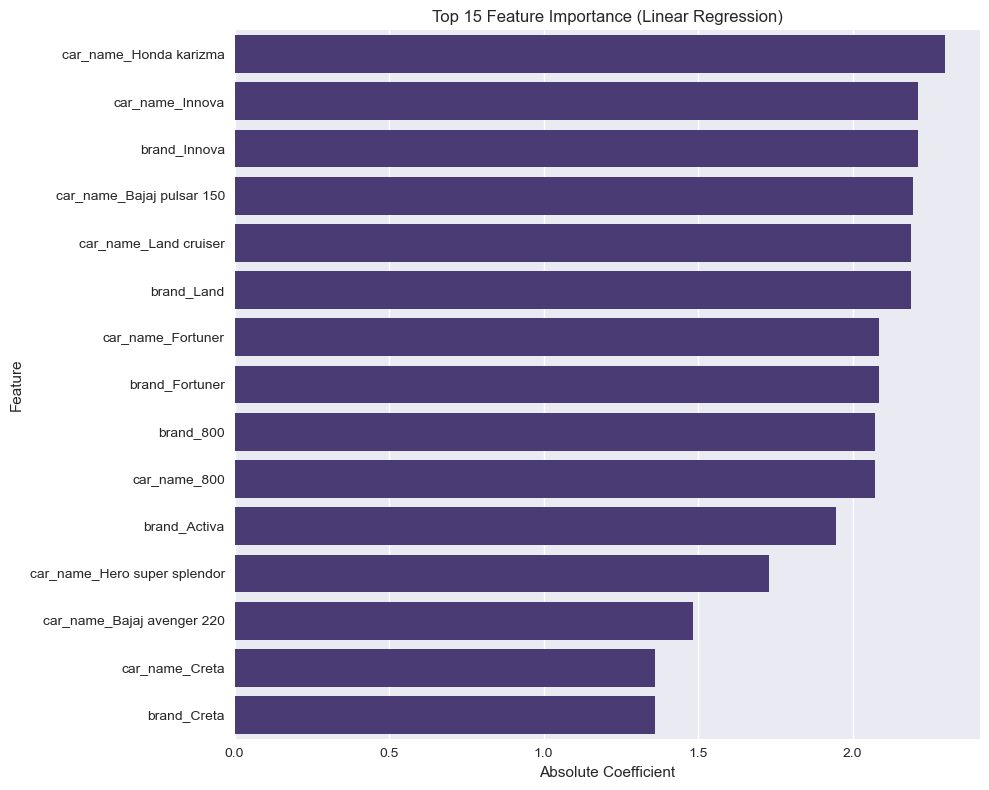

In [37]:
plt.figure(figsize=(10, 8))

sns.barplot(data=coef_df.head(15), x="Importance",y="Feature")

plt.title("Top 15 Feature Importance (Linear Regression)")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Show Positive vs. Negative Effects

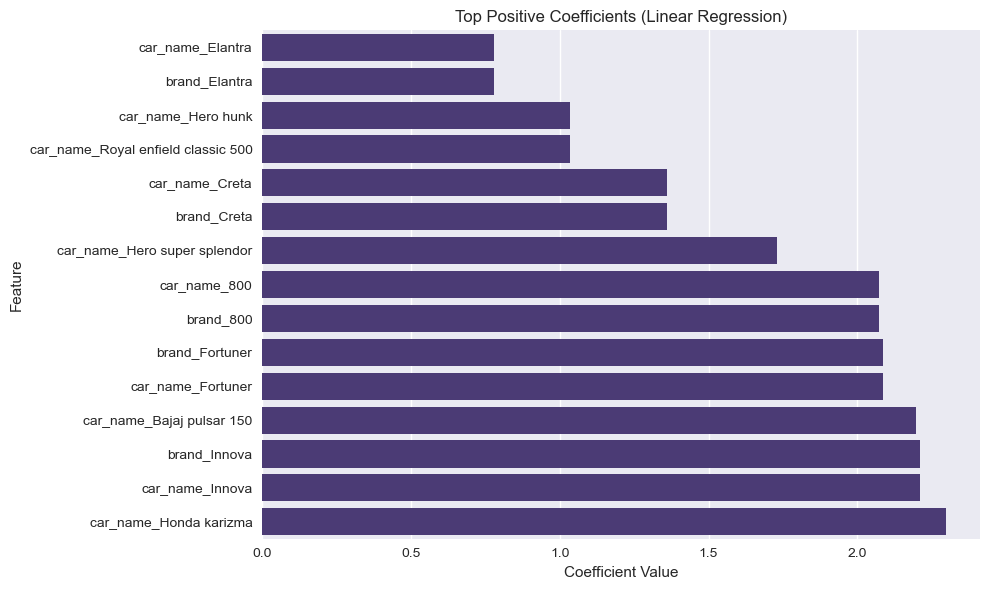

In [38]:
coef_df = coef_df.sort_values(by="Coefficient")

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.tail(15),x="Coefficient",y="Feature")

plt.title("Top Positive Coefficients (Linear Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()